## Part 3: Model Development and Evaluation

Picking up straight from Part 2, same cleaned dataframe, same feature decisions (no `sale_date`, the confounding issue from Part 2 means I leave it out). In this section I build three different regression approaches, state which model I expect to perform best before testing, and then test that expectation that against the actual k-fold CV results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
np.random.seed(42)

## 3.1 Rebuilding from Part 2, with one deliberate difference

The process is mostly the same as Part 2, loading, cleaning, the `_missing` flags. I do not use `sale_date` or `sale_month` as model features given the suburb/time confound flagged there.

The main deliberate change is: Part 2 imputed the missing land size, parking, and bathroom values using medians computed across the whole dataset, which was fine there since Part 2 was exploration, not modelling, there was no train/test split to leak across yet. Here in Part 3, where I am training and evaluating models, that same approach would be a real leak, the test set would quietly influence the values used to fill training rows. So below I split first and then fit the imputation medians on the training data only and apply those exact values to the test set, the way Part 2 exploration did not need to but Part 3 modelling does.

In [2]:
df = pd.read_csv('sydney_housing_final.csv')
df = df.drop(columns=['agent_description_snippet'])
df['sale_date'] = pd.to_datetime(df['sale_date'], format='%d %b %Y')

# Flag columns are based on raw isna(), a structural fact about each row, not a
# statistic computed across rows, so creating these before the split is fine.
df['land_size_missing'] = df['land_size_sqm'].isna().astype(int)
df['parking_missing'] = df['parking_spaces'].isna().astype(int)
df['bathrooms_missing'] = df['bathrooms'].isna().astype(int)

print('shape:', df.shape)
print('flags created, land/parking/bathroom still have real NaNs at this point:')
print(df[['land_size_sqm','parking_spaces','bathrooms']].isna().sum())

shape: (114, 13)
flags created, land/parking/bathroom still have real NaNs at this point:
land_size_sqm     65
parking_spaces    39
bathrooms          2
dtype: int64


## 3.2 Feature set, train/test split, and leakage-safe imputation

The features used here are: `suburb`, `property_type` (both categorical, one-hot encoded), `bedrooms`, `bathrooms`, `parking_spaces`, `land_size_sqm`, along with the three `_missing` flags so the models can identify where a value was imputed instead of observed. Target is `sale_price`.

Holding out 20% as a final untouched test set, and doing the split **before** filling any missing values, not after. The median-by-property-type fill has to be fitted on the training data only and then applied to the test set using those same fitted values, otherwise the test rows influence the numbers used to fill the training rows, a real leak, not a theoretical one. Everything in Part 3 (model comparison, CV, tuning) happens only on the training 80%, the test set does not get touched again until Part 5 final evaluation.

In [3]:
feature_cols = ['suburb', 'property_type', 'bedrooms', 'bathrooms', 'parking_spaces',
                'land_size_sqm', 'land_size_missing', 'parking_missing', 'bathrooms_missing']
X = df[feature_cols].copy()
y = df['sale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)

# Fit the median-by-type fill on X_train only, then apply those exact fitted values to both
# X_train and X_test. No statistic here is ever computed using a test-set row.
land_median_by_type_train = X_train.groupby('property_type')['land_size_sqm'].median()
land_overall_median_train = X_train['land_size_sqm'].median()

parking_median_by_type_train = X_train.groupby('property_type')['parking_spaces'].median()

bath_median_by_type_train = X_train.groupby('property_type')['bathrooms'].median()

def apply_imputation(X):
    X = X.copy()
    X['land_size_sqm'] = X['land_size_sqm'].fillna(X['property_type'].map(land_median_by_type_train))
    X['land_size_sqm'] = X['land_size_sqm'].fillna(land_overall_median_train)
    mask_studio = X['property_type'] == 'Studio'
    X.loc[mask_studio, 'parking_spaces'] = X.loc[mask_studio, 'parking_spaces'].fillna(0)
    X['parking_spaces'] = X['parking_spaces'].fillna(X['property_type'].map(parking_median_by_type_train))
    X['bathrooms'] = X['bathrooms'].fillna(X['property_type'].map(bath_median_by_type_train))
    return X

X_train = apply_imputation(X_train)
X_test = apply_imputation(X_test)

print()
print('missing in model-relevant columns, train:', X_train[['land_size_sqm','parking_spaces','bathrooms']].isna().sum().sum())
print('missing in model-relevant columns, test: ', X_test[['land_size_sqm','parking_spaces','bathrooms']].isna().sum().sum())
print()
print('House land size median, train-only fit:', round(land_median_by_type_train['House'],1))

train: (91, 9) | test: (23, 9)

missing in model-relevant columns, train: 0
missing in model-relevant columns, test:  0

House land size median, train-only fit: 486.8


## 3.3 The three models, and what I expect before running anything

**Model 1: Linear Regression.** This is the simplest baseline. It assumes a straight-line relationship between each feature and price, no interactions, no curves. I expect this model to perform the weakest, Part 2 already indicated land size behaves quite differently by suburb (strong in Blacktown and Marrickville, weak in Paddington), and a plain linear model cannot capture that kind of suburb-dependent effect unless I explicitly build interaction terms in, which I am not doing here. Its strength is that it is fully interpretable, every coefficient has a clear dollar-per-unit meaning.

**Model 2: Decision Tree Regressor.** Splits the data into rectangular regions and predicts the average price in each region. Naturally handles the kind of suburb-dependent, non-linear behaviour Linear Regression cannot, a tree can just split on suburb first and then treat land size differently in each branch. Weakness is that a single tree, especially unconstrained, tends to overfit small datasets like this one (only 91 training rows), memorising individual properties instead of learning general patterns.

**Model 3: Random Forest Regressor.** An ensemble of many decision trees, each trained on a bootstrap sample with a random subset of features, averaged together. Should fix the single trees overfitting problem while keeping its ability to model non-linear, suburb-dependent effects. My prediction going in is that **Random Forest wins**, it gets the flexibility of trees without the single-tree instability, but I am genuinely unsure by how much given how small this dataset is, small data is exactly where the gap between a well-tuned linear model and a complex ensemble can narrow.

In [4]:
categorical_features = ['suburb', 'property_type']
numeric_features = ['bedrooms', 'bathrooms', 'parking_spaces', 'land_size_sqm',
                     'land_size_missing', 'parking_missing', 'bathrooms_missing']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features),
])

models = {
    'Linear Regression': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
    'Decision Tree': Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(random_state=42))]),
    'Random Forest': Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42, n_estimators=200))]),
}
print('pipelines built:', list(models.keys()))

pipelines built: ['Linear Regression', 'Decision Tree', 'Random Forest']


## 3.4 Cross-validated comparison

I use 5-fold CV on the training data only. I use MAE as the main metric because it can be understood directly in dollars, along with RMSE (which gives more weight to large errors) and R² (how much variance is explained). Because there are only 91 training rows, 5-fold means roughly 18 rows held out each fold, small enough that I will also look at the spread across folds, not just the mean.

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'}

results = {}
for name, pipe in models.items():
    cv = cross_validate(pipe, X_train, y_train, cv=kf, scoring=scoring, return_train_score=True)
    results[name] = cv
    print(f"{name}:")
    print(f"  CV MAE  = {-cv['test_MAE'].mean():,.0f}  (+/- {cv['test_MAE'].std():,.0f})")
    print(f"  CV RMSE = {-cv['test_RMSE'].mean():,.0f}")
    print(f"  CV R2   = {cv['test_R2'].mean():.3f}  (+/- {cv['test_R2'].std():.3f})")
    print(f"  train R2 (in-sample) = {cv['train_R2'].mean():.3f}")
    print()

Linear Regression:
  CV MAE  = 729,999  (+/- 746,665)
  CV RMSE = 1,964,606
  CV R2   = -8.010  (+/- 17.576)
  train R2 (in-sample) = 0.853

Decision Tree:
  CV MAE  = 343,194  (+/- 68,682)
  CV RMSE = 522,843
  CV R2   = 0.762  (+/- 0.083)
  train R2 (in-sample) = 0.993

Random Forest:
  CV MAE  = 335,630  (+/- 52,783)
  CV RMSE = 508,784
  CV R2   = 0.775  (+/- 0.045)
  train R2 (in-sample) = 0.957



I first read these results carefully before writing anything about them.

In [6]:
summary = pd.DataFrame({
    name: {
        'CV MAE': -cv['test_MAE'].mean(),
        'CV RMSE': -cv['test_RMSE'].mean(),
        'CV R2': cv['test_R2'].mean(),
        'CV R2 std': cv['test_R2'].std(),
        'Train R2': cv['train_R2'].mean(),
    }
    for name, cv in results.items()
}).T
summary

,CV MAE,CV RMSE,CV R2,CV R2 std,Train R2
Linear Regression,729998.585923,1.964606e+06,-8.009664,17.575734,0.853271
Decision Tree,343194.249513,5.228430e+05,0.762174,0.083298,0.992914
Random Forest,335629.767440,5.087843e+05,0.775451,0.045125,0.956783


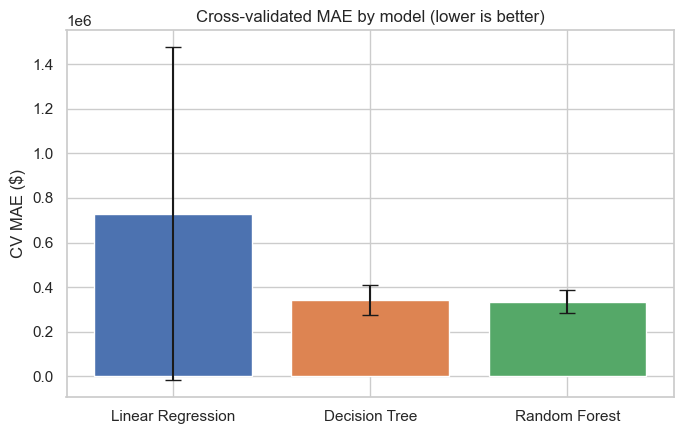

In [7]:
fig, ax = plt.subplots(figsize=(7,4.5))
names = list(results.keys())
mae_vals = [-results[n]['test_MAE'].mean() for n in names]
mae_stds = [results[n]['test_MAE'].std() for n in names]
ax.bar(names, mae_vals, yerr=mae_stds, capsize=6, color=['#4C72B0','#DD8452','#55A868'])
ax.set_ylabel('CV MAE ($)')
ax.set_title('Cross-validated MAE by model (lower is better)')
plt.tight_layout()
plt.show()

One result stands out immediately before interpreting the table: Linear Regression CV R² is -8.01. This is worse than simply predicting the mean for every case, and it is a much larger failure than I originally expected (I originally expected it to do worst, but not catastrophically badly). Before deciding "which model wins", I want to understand why this happened instead of only reporting the scary number.

In [8]:
fold_scores = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
    fold_scores[name] = scores
    print(f'{name} per-fold R2: {np.round(scores,3)}')

Linear Regression per-fold R2: [  0.788   0.812   0.75    0.762 -43.161]
Decision Tree per-fold R2: [0.647 0.757 0.821 0.883 0.704]
Random Forest per-fold R2: [0.793 0.811 0.704 0.826 0.743]


In [9]:
# Dig into fold 4 specifically: what's in the test set, and what's the worst prediction?
for fold_i, (tr_idx, te_idx) in enumerate(kf.split(X_train)):
    if fold_i == 4:
        lr_pipe = models['Linear Regression']
        lr_pipe.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        preds = lr_pipe.predict(X_train.iloc[te_idx])
        fold4 = pd.DataFrame({
            'actual': y_train.iloc[te_idx].values,
            'predicted': preds,
            'property_type': X_train.iloc[te_idx]['property_type'].values,
            'suburb': X_train.iloc[te_idx]['suburb'].values,
            'land_size_missing': X_train.iloc[te_idx]['land_size_missing'].values,
        })
        fold4['abs_error'] = (fold4['actual'] - fold4['predicted']).abs()

        print('property types present in fold 4 test set:')
        print(X_train.iloc[te_idx]['property_type'].value_counts())
        print()
        print('worst 3 predictions in fold 4:')
        print(fold4.sort_values('abs_error', ascending=False).head(3).to_string())
        print()
        worst_idx = fold4['abs_error'].idxmax()
        r2_excl_worst = 1 - ((fold4['actual']-fold4['predicted'])**2).drop(worst_idx).sum() / \
                            ((fold4['actual']-fold4['actual'].mean())**2).drop(worst_idx).sum()
        print(f'fold 4 R2 excluding the single worst point: {r2_excl_worst:.3f}')

property types present in fold 4 test set:
property_type
House        8
Apartment    8
Unit         1
Terrace      1
Name: count, dtype: int64

worst 3 predictions in fold 4:
     actual     predicted property_type      suburb  land_size_missing     abs_error
12  2360000 -3.085403e+07         House  Paddington                  1  3.321403e+07
4   4250000  2.869139e+06         House  Paddington                  1  1.380861e+06
14  3965000  2.880882e+06         House  Paddington                  1  1.084118e+06

fold 4 R2 excluding the single worst point: 0.812


The fold results make it clear. Linear Regression records a reasonable 0.75 to 0.81 on 4 of the 5 folds, but then drops to -43.2 on the 5th. That one extremely poor fold is entirely responsible for pulling the average down to -8 and greatly increasing the standard deviation to 17.6.

I checked exactly what was happening in that fold instead of guessing. It comes down to one row, a Paddington House whose land size was imputed (not observed) that the model predicts at roughly **-$30.9 million** against an actual sale price of $2.36 million. Drop that single point and the folds R² jumps to 0.81, right in line with the other four folds. I also checked whether this is about rare property types landing in the test fold, my first instinct, but that is not it, the test set for this fold has no Studio or Townhouse rows at all, just House, Apartment, Unit, and Terrace. So the failure is not "a rare category showed up", it is one specific high-leverage point (a House with an imputed land size) receiving an extreme prediction from an unregularised linear model.

The underlying cause is still about sample size and model capacity: after one-hot encoding I have got 14 feature columns fit from only around 72 training rows per fold, and with no regularisation, ordinary least squares can end up with wildly large coefficients whenever the training data does not tightly constrain them. That is usually fine (it does not cause a problem in 4 of 5 folds), but it means the model is fragile, and every so often a single point in the test fold lands somewhere those unconstrained coefficients extrapolate badly. I want to test that explanation instead of just assert it, so let me check whether regularisation (Ridge, which directly penalises large coefficients) actually fixes it.

In [10]:
from sklearn.linear_model import Ridge

for alpha in [10, 100, 300, 1000]:
    rp = Pipeline([('prep', preprocessor), ('model', Ridge(alpha=alpha))])
    scores = cross_val_score(rp, X_train, y_train, cv=kf, scoring='r2')
    print(f'Ridge alpha={alpha:>5}: per-fold {np.round(scores,3)}  |  mean {scores.mean():.3f}  std {scores.std():.3f}')

Ridge alpha=   10: per-fold [  0.625   0.574   0.488   0.552 -60.206]  |  mean -11.593  std 24.307
Ridge alpha=  100: per-fold [ 0.414  0.416  0.259  0.304 -2.936]  |  mean -0.309  std 1.315
Ridge alpha=  300: per-fold [0.239 0.27  0.154 0.162 0.053]  |  mean 0.176  std 0.076
Ridge alpha= 1000: per-fold [0.08  0.111 0.055 0.037 0.091]  |  mean 0.075  std 0.026


The results are more mixed than I first expected. Weak regularisation (alpha=10) does not improve the result, the same fold becomes even worse (-60.2 instead of -43.2) and the overall mean drops further to -11.6. Alpha=100 is still negative overall (mean -0.31), that fold improves a lot (-2.9, versus -43.2 unregularised) but has not been tamed completely. It is not until **alpha=300** that every single fold turns positive (0.05 to 0.27) and the mean reaches 0.176, a properly stable result. Pushing regularisation further (alpha=1000) actually makes things worse again (mean drops to 0.075), the model is now so constrained it cannot fit much of anything.

So there is a real sweet spot, too little regularisation does not stabilise the wild coefficients, too much throws away real signal along with the instability, and even at the best point I found (alpha=300, mean R² 0.176), Ridge is still far behind the Decision Tree (0.762) or Random Forest (0.775). Regularisation can stabilise the linear model, it cannot make it competitive.

That is consistent with what Part 2 found: land size behaves very differently across the three suburbs (correlations of 0.81, 0.88, and 0.37), which is exactly the kind of non-linear, interaction-driven pattern a plain linear model cannot capture without someone manually building suburb-by-feature interaction terms in. The instability problem and the underperformance problem are genuinely two separate issues, one is about sample size, rare high-leverage points, and the amount of regularisation, the other is about the model class being fundamentally unable to represent the relationship in this data. Fixing the first (with the right amount of regularisation) does not fix the second.

After looking at the comparison table more carefully now that the main cause is clear: Random Forest has the strongest results across the main metrics, CV MAE of $335,630 versus $343,194 for the Decision Tree and $729,999 for Linear Regression (which, as covered above, is mainly being pulled down by one high-leverage point in one fold instead of performing poorly in every fold). Random Forest also has the highest CV R² (0.775 vs 0.762 for the tree) and, importantly, the smallest standard deviation across folds (0.045 vs 0.083 for the tree), so its average performance is stronger and its results are also more consistent between folds. This consistency is important given how small this dataset is, a model whose score changes sharply between folds would be difficult to rely on a single future prediction.

The Decision Tree performs clearly better than Linear Regression (0.762 vs the linear models troubled -8.01), which supports my original prediction that a single tree would handle the non-linear, suburb-dependent relationships better than a straight-line model. But it does not reach the same results as Random Forest, which is reasonable given the averaging-across-many-trees mechanism is designed to reduce the kind of instability a single tree is prone to, and Random Forests much tighter fold-to-fold spread (std 0.045 vs the trees 0.083) shows that averaging effect directly.

## 3.5 Underfitting, overfitting, and the bias-variance trade-off

The difference between train R² and CV R² in the table above is the main diagnostic here. A model that fits the training data extremely closely but does much worse on unseen validation folds is overfitting, learning details from the training data instead of a pattern that generalises. A model that does badly on both is underfitting, not flexible enough to capture the actual relationship.

In [11]:
gap_df = summary[['Train R2', 'CV R2']].copy()
gap_df['Gap (Train - CV)'] = gap_df['Train R2'] - gap_df['CV R2']
gap_df

,Train R2,CV R2,Gap (Train - CV)
Linear Regression,0.853271,-8.009664,8.862934
Decision Tree,0.992914,0.762174,0.230740
Random Forest,0.956783,0.775451,0.181332


Linear Regression train R² (0.853) looks reasonable by itself, this is not really a standard underfitting case where the model is too simple to fit even the training data. The problem is mainly a generalisation problem, the large train-to-CV gap (8.86) reflects the instability diagnosed above (one high-leverage imputed point disrupting an unregularised model) instead of the model failing to learn the training set. I would describe this more as a high-variance failure mode caused in part by having many parameters (14 encoded features) compared with the small number of training rows (91), instead of textbook overfitting in the sense of memorising noise.

Decision Tree shows a clear overfitting pattern: train R² of 0.993 is very close to perfect, effectively fitting the training rows, while CV R² drops to 0.762, a real gap (0.231). An unconstrained tree with this little data has enough flexibility to carve out a leaf for almost every training point, which helps explain the near-perfect training fit and the weaker generalisation.

Random Forest is fairly close to the Decision Tree on train R² (0.957, still fits the training data strongly since individual trees inside the forest are also grown deep) but has the smallest train-to-CV gap of all three (0.181). Averaging over 200 trees, each seeing a different bootstrap sample and a different random subset of features at each split, reduces much of the idiosyncratic overfitting any single tree develops, which is the main bias-variance trade-off that ensemble methods are designed to handle, individual high-variance trees average out to something with much lower variance overall, without giving up much of the low-bias flexibility trees have that Linear Regression lacks.

## 3.6 Revisiting my original prediction

My original prediction was that Random Forest would perform best, and it did, on every CV metric. That expectation was supported by the results: I originally expected it to combine the non-linear flexibility of trees with the variance-reduction of averaging, and the results support that directly (smallest train-CV gap, best CV R², best CV MAE, most consistent across folds).

What I did not expect was quite how badly Linear Regression would fail, and more importantly, the reason behind it. I originally expected it to underperform because it cannot capture suburb-dependent, non-linear relationships, and the results support that, even a carefully regularised version (Ridge, best case around alpha=300, mean R² 0.176) still falls well short of the tree-based models. However, I did not expect the specific mechanism behind the CV R² collapsing so dramatically, a single high-leverage point (a Paddington House with imputed land size) appearing in one test fold and receiving an extreme prediction from an unregularised model. My first explanation (a rare property type landing in the test fold) was not correct once I checked the folds contents, it had no Studio or Townhouse rows at all. Looking more closely at the per-fold scores and the specific row responsible, instead of relying only on either the aggregate CV number or my first plausible-sounding explanation, helped identify the actual reason.

## 3.7 Final model selection and justification

**Random Forest is the selected model**, based on the results above: best CV MAE ($335,630), best CV R² (0.775), and most importantly, the smallest and most stable train-CV gap (0.181 vs 0.231 for the tree and 8.86 for linear regression), meaning its cross-validated performance is the most useful estimate of how it will perform on new properties.

The Random Forest performs better than the Decision Tree because averaging over many trees helps address the single trees overfitting problem while keeping the same main ability to model suburb-dependent, non-linear relationships that Part 2 exploration showed this data shows in the data (the land size effect that is strong in Blacktown and Marrickville but weak in Paddington is exactly the kind of pattern a tree-based method can capture without manually defining the interaction). It beats Linear Regression for two main reasons, first, the structural issue (it cannot represent the non-linear relationship at all, even the best-tuned regularised version tops out around R² 0.18) and second, the practical issue this datasets small size and rare high-leverage points expose (unregularised OLS is dangerously unstable here, and even after stabilising it with the right amount of Ridge regularisation, it is still the weakest model by a wide margin).

I will use this model for to Part 4s error analysis and Part 5 final evaluation the untouched test set. Given the mechanism found above, that specific Paddington House with imputed land size is a useful case to check again in Part 4, if Random Forest also has trouble with it, that is a genuinely informative finding about where this whole modelling approach has real limits, not just something specific to Linear Regressions fragility.